# day-25-good-evals — worked solutions & answer key

Solutions to the exercises in [`../lesson.ipynb`](../lesson.ipynb), plus the self-check answer key. **Try each exercise yourself first** — the value is in the attempt, not the answer.

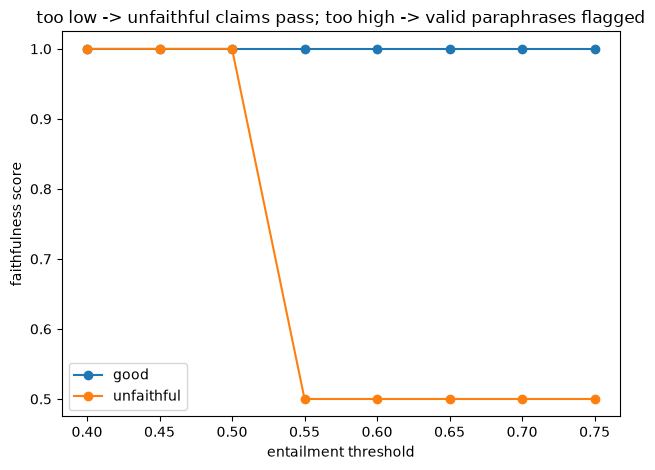

In [8]:
# ---- Solution 1 ----
import matplotlib.pyplot as plt
ths = np.linspace(0.4, 0.75, 8)
for name, a in [("good", ANSWER_GOOD), ("unfaithful", ANSWER_UNFAITHFUL)]:
    claims = [c.strip() for c in re.split(r"(?<=[.!?])\s+", a) if len(c.strip()) > 12]
    cv = E(CONTEXT); scores = [float(np.max(cv @ E(c)[0])) for c in claims]
    ys = [np.mean([s >= th for s in scores]) for th in ths]
    plt.plot(ths, ys, "o-", label=name)
plt.xlabel("entailment threshold"); plt.ylabel("faithfulness score"); plt.legend()
plt.title("too low -> unfaithful claims pass; too high -> valid paraphrases flagged"); plt.tight_layout(); plt.show()

In [9]:
# ---- Solution 3 ----
def pairwise_biased(q, ctx, first, second, first_label, second_label):
    s = {first_label: 0.5*faithfulness(first, ctx)[0] + 0.5*min(1, relevance(first, q)/0.6) + 0.4,
         second_label: 0.5*faithfulness(second, ctx)[0] + 0.5*min(1, relevance(second, q)/0.6)}
    return max(s, key=s.get)

def debiased(q, ctx, a, b):
    r1 = pairwise_biased(q, ctx, a, b, "A", "B")
    r2 = pairwise_biased(q, ctx, b, a, "B", "A")
    return r1 if r1 == r2 else "tie"

print("biased single-run:", pairwise_biased(QUESTION, CONTEXT, ANSWER_GOOD, ANSWER_UNFAITHFUL, "A", "B"),
      "(A wins just for being first)")
print("debiased (swap+agree):", debiased(QUESTION, CONTEXT, ANSWER_GOOD, ANSWER_UNFAITHFUL))

biased single-run: A (A wins just for being first)
debiased (swap+agree): tie


In [10]:
# ---- Solution 6 ----
def mini_report(rows):
    print(f"{'relev':>6}{'faith':>7}{'fmt':>5}{'words':>7}  verdict  question")
    for q, ctx, a in rows:
        r = relevance(a, q); f = faithfulness(a, ctx)[0]
        try: json.loads(re.search(r"\{.*\}", a, re.S).group()); fmt = 1
        except Exception: fmt = 0
        verdict = "PASS" if (f >= 0.8 and r >= 0.3) else "fail"
        print(f"{r:>6.2f}{f:>7.2f}{fmt:>5}{len(a.split()):>7}  {verdict:>7}  {q[:40]}")

mini_report([
 (QUESTION, CONTEXT, ANSWER_GOOD),
 (QUESTION, CONTEXT, ANSWER_UNFAITHFUL),
 (QUESTION, CONTEXT, ANSWER_IRRELEVANT),
])

 relev  faith  fmt  words  verdict  question


  0.82   1.00    0     15     PASS  How long do refunds take and do I need t
  0.87   0.50    0     14     fail  How long do refunds take and do I need t
  0.05   0.00    0     12     fail  How long do refunds take and do I need t


### Solutions 2, 4, 5 (sketch)

**S2:** e.g. gold "42" / pred "forty-two" (EM 0, F1 0, sim high); gold "The capital is Paris" /
pred "Paris" (EM 0, F1 low, sim mid); gold "yes" / pred "Yes, absolutely" (EM 0, F1 mid).
Trust: (a) math → EM after normalisation; (b) summary → judge / faithfulness (n-gram metrics
lie); (c) yes/no → EM on a normalised label.

**S4:** the length-penalty line pulls the judge's score for `a_long` down toward the human's 4,
lowering MAE — *if* humans actually dislike the padding. Calibrate the rubric change against
the human set; don't assume it helps.

**S5:** with agreement ≥ 5/7, easy questions (6/7 agree) auto-answer, hard ones (max 1–2 agree)
route to review. Over a 50/50 mix you'd auto-answer ~50%. Lower the bar to 4/7 and you
auto-answer more but let through more low-confidence answers — tune against how bad a wrong
auto-answer is.

### Answer key
1. Valid (measures what you care about), reliable (repeatable), sensitive (moves with
   quality), cheap enough to run often.
2. An answer can be correct but unfaithful — the fact came from the model's weights, not the
   retrieved context — so the retriever is silently broken and will produce a confident wrong
   answer on the next question where the model's prior is wrong.
3. A fluent correct paraphrase with different words scores low (little n-gram overlap with the
   reference); a disfluent string that happens to contain the reference's words scores high.
4. Any three: verbosity/length (instruct to ignore length, penalise padding); position
   (swap-and-average in pairwise); self-preference (use a different judge model / ensemble);
   sycophancy (rubric weights evidence over confident tone); format halo (judge content only).
5. Calibrate it against human labels on a sample (50–100), reporting MAE and rank correlation;
   fix the rubric until it correlates.
6. Property checks (faithfulness, format, safety, on-topic); self-consistency across N
   samples; calibrated LLM-judge with a rubric; pairwise-vs-baseline; human review of a
   sample.
7. Offline: a frozen curated set, "is the new version better?", has ground truth. Production:
   live unlabelled shifting traffic, "is quality holding / anything on fire?", rarely has
   ground truth (relies on property checks, sampled judge, user signals).